
# Hybrid Rating Prediction: Mistral-7B-Instruct + Quantum Grover (Amazon-Book, HuggingFace)

Ce notebook implémente un pipeline **hybride** pour la prédiction de rating (1–5 étoiles) sur le dataset **Amazon-Reviews-2023-Books-Review** disponible sur Hugging Face :

- Un **LLM** (`mistralai/Mistral-7B-Instruct-v0.2`) estime le rating à partir du texte de la review.
- Un **circuit quantique de type Grover** est utilisé pour modéliser/amplifier la classe cible dans un espace de 5 ratings possibles.
- Un **pipeline complet** permet de tester le modèle sur un sous-ensemble du dataset, d'évaluer les performances (Accuracy, MAE, RMSE) et de visualiser les erreurs via des graphiques.

Le dataset est chargé directement depuis Hugging Face :
```python
from datasets import load_dataset
ds = load_dataset("cogsci13/Amazon-Reviews-2023-Books-Review", "raw_review_Books", split="full", trust_remote_code=True)
```


## 1. Imports

In [51]:
!nvidia-smi

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Thu Dec  4 16:21:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:E1:00.0 Off |                    0 |
| N/A   31C    P0             79W /  350W |   14791MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [52]:

!pip install transformers accelerate sentencepiece pennylane pandas scikit-learn datasets matplotlib -q

import os
import json
import math
import random
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

import pennylane as qml

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import torch
import matplotlib.pyplot as plt


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


You should consider upgrading via the '/faststorage/project/DEIC-SDU-L2-22/env/bin/python3 -m pip install --upgrade pip' command.


## 2. Configuration

In [54]:

# Dataset HuggingFace
HF_DATASET_NAME = "cogsci13/Amazon-Reviews-2023-Books-Review"
HF_CONFIG_NAME = "default"
HF_SPLIT = "full"

# Champs d'intérêt dans le dataset HF
TEXT_COL = "text"      # cf. description HF
RATING_COL = "rating"  # float 1.0-5.0

MAX_SAMPLES = 1000     # nombre max de reviews pour nos expériences

# LLM
LLM_NAME = "mistralai/Mistral-7B-Instruct-v0.2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_NEW_TOKENS = 128
TEMPERATURE = 0.1

# Quantum / Grover
N_RATINGS = 5
N_QUBITS = 3           # 2^3 = 8 >= 5
N_SHOTS = 512
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


## 3. Chargement du dataset Hugging Face (Amazon-Reviews-2023-Books-Review)

In [55]:

print("Chargement du dataset depuis Hugging Face...")
ds = load_dataset(HF_DATASET_NAME, HF_CONFIG_NAME, split=HF_SPLIT, trust_remote_code=True)

print(ds)
print("Exemple brut ds[0]:")
print(ds[0])

# On échantillonne un sous-ensemble pour éviter de tout utiliser
if MAX_SAMPLES is not None and len(ds) > MAX_SAMPLES:
    ds_sub = ds.shuffle(seed=RANDOM_SEED).select(range(MAX_SAMPLES))
else:
    ds_sub = ds

print("\nSous-ensemble utilisé :", len(ds_sub))

# Conversion en DataFrame
df = ds_sub.to_pandas()

# rating est un float dans [1.0, 5.0], on le force en int
df[RATING_COL] = df[RATING_COL].round().astype(int)

# On garde uniquement les colonnes nécessaires
df = df[[TEXT_COL, RATING_COL]].dropna().reset_index(drop=True)

print("DataFrame final:", df.shape)
df.head()


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cogsci13/Amazon-Reviews-2023-Books-Review' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Chargement du dataset depuis Hugging Face...
Dataset({
    features: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'],
    num_rows: 29475453
})
Exemple brut ds[0]:
{'rating': 1.0, 'title': 'Not a watercolor book! Seems like copies imo.', 'text': 'It is definitely not a watercolor book.  The paper bucked completely.  The pages honestly appear to be photo copies of other pictures. I say that bc if you look at the seal pics you can see the tell tale line at the bottom of the page.  As someone who has made many photocopies of pages in my time so I could try out different colors & mediums that black line is a dead giveaway to me. It’s on other pages too.  The entire book just seems off. Nothing is sharp & clear. There is what looks like toner dust on all the pages making them look muddy.  There are no sharp lines & there is no clear definition.  At least there isn’t in my copy.  And the Coloring Book for Adult on the 

,text,rating
0,Me encantan las joyas y este es un libro precioso,5
1,beautiful book and inspiring recipes,4
2,This is an amazing book. The real story from t...,5
3,"Quite a read, though the plot was a bit thin c...",5
4,Very mixed feelings about this one. I kept rea...,3


## 4. Chargement du LLM Mistral-7B-Instruct

In [56]:
tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
model = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
model.to(DEVICE)+.
print("Modèle chargé sur :", DEVICE)


Loading checkpoint shards: 100%|█████████████████████████████████████████████████████████| 3/3 [05:02<00:00, 100.93s/it]


Modèle chargé sur : cuda


## 5. Helpers LLM : prompt & parsing

In [57]:
SYSTEM_PROMPT = """You are an expert analyst of Amazon BOOK reviews.

Your task is to read a user review about a BOOK and infer:
- the SENTIMENT polarity: negative / neutral / positive
- the INTENSITY of this sentiment: a value between 0 and 1

You MUST respond in valid JSON, and ONLY valid JSON, with the following fields:
- "sentiment": one of "negative", "neutral", "positive"
- "intensity": float between 0 and 1 (0 = very weak, 1 = very strong)
- "reasoning": short text explaining why this sentiment and intensity were predicted

Do NOT add any text before or after the JSON. Do NOT add markdown or code blocks.
"""


def build_prompt_from_review(review_text: str) -> str:
    prompt = f"""{SYSTEM_PROMPT}

Review:
{review_text}

Now output ONLY the JSON object:
"""
    return prompt


def call_mistral(review_text: str):
    prompt = build_prompt_from_review(review_text)
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,   # sortie plus déterministe
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # print("=== RAW ==="); print(generated)  # debug éventuel

    # On cherche le premier JSON { ... }
    start = generated.find("{")
    end = generated.rfind("}")
    if start == -1 or end == -1 or end <= start:
        return {
            "sentiment": "neutral",
            "intensity": 0.0,
            "reasoning": "no json found",
            "raw": generated,
        }

    json_str = generated[start:end+1]

    try:
        data = json.loads(json_str)
    except Exception:
        data = {
            "sentiment": "neutral",
            "intensity": 0.0,
            "reasoning": "fallback parse error",
            "raw": generated,
        }

    # Nettoyage
    sentiment = str(data.get("sentiment", "neutral")).lower()
    if sentiment not in ["negative", "neutral", "positive"]:
        sentiment = "neutral"

    try:
        intensity = float(data.get("intensity", 0.0))
    except Exception:
        intensity = 0.0
    intensity = max(0.0, min(1.0, intensity))

    data["sentiment"] = sentiment
    data["intensity"] = intensity
    return data


In [58]:
def sentiment_to_prior_rating(sentiment: str, intensity: float) -> float:
    """
    Mappe (sentiment, intensity) -> rating continu dans [1, 5].

    Idée :
      - negative  -> entre 1 et 2.5
      - neutral   -> autour de 3
      - positive  -> entre 3.5 et 5
    """
    sentiment = sentiment.lower()
    intensity = max(0.0, min(1.0, float(intensity)))

    if sentiment == "negative":
        # 1 (très négatif) -> 2.5 (plutôt mitigé)
        return 1.0 + 1.5 * (1.0 - intensity)  # intensity=1 ->1.0, intensity=0 ->2.5
    elif sentiment == "neutral":
        # Autour de 3 ± un peu
        return 2.5 + 1.0 * (intensity - 0.5)  # intensity=0.5 ->2.5, 0->2, 1->3
    elif sentiment == "positive":
        # 3.5 (faiblement positif) -> 5 (très enthousiaste)
        return 3.5 + 1.5 * intensity         # intensity=0 ->3.5, intensity=1 ->5
    else:
        return 3.0  # fallback neutre


In [17]:
# SYSTEM_PROMPT = """You are an expert analyst of Amazon BOOK reviews.

# Your task is to read a user review about a BOOK and infer the STAR RATING the user would give on Amazon.

# The rating must be an INTEGER between 1 and 5, where:
# 1 = very negative opinion
# 2 = negative opinion
# 3 = mixed / neutral opinion
# 4 = positive opinion
# 5 = very positive opinion

# You MUST respond in valid JSON, and ONLY valid JSON, with the following structure:

# {
#   "rating": <integer 1-5>,
#   "confidence": <float between 0 and 1>,
#   "reasoning": "<short explanation>"
# }

# Do NOT add any text before or after the JSON. Do NOT add markdown or code blocks.
# """


# def build_prompt_from_review(review_text: str) -> str:
#     prompt = f"""{SYSTEM_PROMPT}

# Review:
# {review_text}

# Now output ONLY the JSON object:
# """
#     return prompt



# def call_mistral(review_text: str):
#     prompt = build_prompt_from_review(review_text)
#     inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

#     with torch.no_grad():
#         outputs = model.generate(
#             **inputs,
#             max_new_tokens=128,
#             do_sample=False,
#         )

#     generated = tokenizer.decode(outputs[0], skip_special_tokens=True)

#     # On tente de trouver un JSON valide en partant de la fin
#     last_brace_pos = [i for i, c in enumerate(generated) if c == "{"]

#     data = None
#     if not last_brace_pos:
#         data = {"rating": 3, "confidence": 0.0, "reasoning": "no json found", "raw": generated}
#     else:
#         end = generated.rfind("}")
#         for start in reversed(last_brace_pos):
#             if start >= end:
#                 continue
#             candidate = generated[start:end+1]
#             try:
#                 data = json.loads(candidate)
#                 break
#             except Exception:
#                 continue
#         if data is None:
#             data = {"rating": 3, "confidence": 0.0, "reasoning": "fallback parse error", "raw": generated}

#     rating = int(data.get("rating", 3))
#     rating = max(1, min(5, rating))
#     data["rating"] = rating
#     return data


### 🔎 Test rapide du LLM sur une review

In [59]:

sample_text = df.loc[0, TEXT_COL]
print("Review exemple :\n", sample_text[:500], "\n")

result = call_mistral(sample_text)
print("Résultat LLM :")
print(result)


Review exemple :
 Me encantan las joyas y este es un libro precioso 



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Résultat LLM :
{'sentiment': 'positive', 'intensity': 1.0, 'reasoning': "The user expresses their love for the book, using the word 'precioso' (precious) to describe it."}


## 6. Partie Quantique : Grover pour 5 ratings (1..5)

In [60]:
n_qubits = N_QUBITS
dev = qml.device("default.qubit", wires=n_qubits, shots=N_SHOTS)

def int_to_basis_bits(x, n_bits):
    return [int(b) for b in format(x, f"0{n_bits}b")]

def oracle(target_index):
    """Oracle de Grover : flip de phase sur l'état 'target_index'."""
    bits = int_to_basis_bits(target_index, n_qubits)

    # Met |target_index> en |11..1> via des X sur les bits à 0
    for i, b in enumerate(bits):
        if b == 0:
            qml.PauliX(wires=i)

    # Multi-controlled X sur le dernier qubit, contrôlé par les autres
    control_wires = list(range(n_qubits - 1))   # ex: [0,1] si n_qubits=3
    target_wire = n_qubits - 1                  # ex: 2
    qml.MultiControlledX(control_wires=control_wires, wires=target_wire)

    # On remet les X
    for i, b in enumerate(bits):
        if b == 0:
            qml.PauliX(wires=i)

def diffuser():
    """Opérateur de diffusion de Grover."""
    # H puis X sur tous les qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.PauliX(wires=i)

    # Multi-controlled X sur le dernier qubit
    control_wires = list(range(n_qubits - 1))
    target_wire = n_qubits - 1
    qml.MultiControlledX(control_wires=control_wires, wires=target_wire)

    # X puis H sur tous les qubits (annulation)
    for i in range(n_qubits):
        qml.PauliX(wires=i)
        qml.Hadamard(wires=i)

def grover_iterations(N, M=1):
    """Nombre optimal d'itérations de Grover pour N états et M solutions."""
    return max(1, round((math.pi / 4.0) * math.sqrt(N / M)))

@qml.qnode(dev)
def grover_circuit(target_index, n_iterations):
    # Superposition uniforme
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    for _ in range(n_iterations):
        oracle(target_index)
        diffuser()

    # On mesure directement les qubits en base informatique |0/1>
    return qml.sample(wires=range(n_qubits))


### 6.1 Helper pour lancer Grover et obtenir un rating

In [61]:
def run_grover_for_rating(prior_rating: int):
    """
    prior_rating : rating prédit par le LLM (1..5)
    On le convertit en index 0..4, puis on applique Grover dans un espace de 2^n_qubits états.
    """
    target_index = prior_rating - 1  # 1..5 -> 0..4
    N = 2 ** n_qubits
    M = 1
    k = grover_iterations(N, M)

    # samples shape: (shots, n_qubits), avec des 0/1
    samples = grover_circuit(target_index, k)
    samples = np.array(samples)

    indices = []
    for row in samples:
        v = 0
        for b in row:
            v = (v << 1) | int(b)
        indices.append(v)

    indices = np.array(indices)

    # On ne garde que les indices correspondant à des ratings valides (0..4)
    indices = indices[indices < N_RATINGS]
    if len(indices) == 0:
        return prior_rating  # fallback : on revient au rating LLM

    # L'indice le plus fréquent
    values, counts = np.unique(indices, return_counts=True)
    best_index = values[np.argmax(counts)]
    quantum_rating = best_index + 1  # 0..4 -> 1..5
    return quantum_rating


## 7. Pipeline Hybride LLM + Quantum

In [62]:
def hybrid_predict(review_text: str):
    """
    Nouveau pipeline :
    1) LLM Mistral prédit (sentiment, intensity)
    2) On mappe (sentiment, intensity) -> rating prior continu (1..5)
    3) On crée un rating discret LLM = arrondi(prior)
    4) Grover prend ce rating LLM comme cible -> quantum_rating
    5) Rating final = fusion pondérée LLM + quantum
    """
    llm_out = call_mistral(review_text)
    sentiment = llm_out["sentiment"]
    intensity = llm_out["intensity"]

    prior_cont = sentiment_to_prior_rating(sentiment, intensity)
    llm_rating = int(round(prior_cont))
    llm_rating = max(1, min(5, llm_rating))

    # Quantum sur la base du rating LLM
    quantum_rating = int(run_grover_for_rating(llm_rating))

    # Pondération : LLM dominant, quantum correction
    base_w_llm = 0.8
    base_w_q = 0.2

    # Pas de confiance ici, donc on garde fixe (tu peux raffiner plus tard)
    w_llm = base_w_llm
    w_q = base_w_q
    s = w_llm + w_q
    w_llm /= s
    w_q /= s

    fused = w_llm * llm_rating + w_q * quantum_rating
    final_rating = int(round(fused))
    final_rating = max(1, min(5, final_rating))

    return {
        "llm_rating": llm_rating,               # rating dérivé du sentiment
        "quantum_rating": quantum_rating,
        "final_rating": final_rating,
        "prior_cont": prior_cont,
        "llm_raw": llm_out,
        "weights": {"w_llm": w_llm, "w_q": w_q},
    }


In [37]:
# def hybrid_predict(review_text: str):
#     """
#     Pipeline hybride :
#     1) LLM Mistral prédit un rating (prior)
#     2) Grover prend ce prior comme cible et renvoie un rating quantique
#     3) Rating final = combinaison pondérée (LLM dominant, quantum léger)
#        - Le quantum influence plus quand la confiance LLM est faible.
#     """
#     llm_out = call_mistral(review_text)
#     llm_rating = int(llm_out["rating"])
#     confidence = float(llm_out.get("confidence", 0.0))

#     # Clamp de sécurité
#     confidence = max(0.0, min(1.0, confidence))

#     # Rating quantique basé sur le prior LLM
#     quantum_rating = int(run_grover_for_rating(llm_rating))

#     # Poids de base : LLM fort, quantum faible
#     base_w_llm = 0.8
#     base_w_q = 0.2

#     # On module par la confiance :
#     # - si confiance haute → le LLM domine encore plus
#     # - si confiance basse → le quantum pèse un peu plus
#     w_llm = base_w_llm + 0.2 * confidence      # ∈ [0.8, 1.0]
#     w_q = base_w_q * (1.0 - confidence)        # ∈ [0.0, 0.2]

#     # Normalisation
#     s = w_llm + w_q
#     w_llm /= s
#     w_q /= s

#     fused = w_llm * llm_rating + w_q * quantum_rating
#     final_rating = int(round(fused))
#     final_rating = max(1, min(5, final_rating))

#     return {
#         "llm_rating": llm_rating,
#         "quantum_rating": quantum_rating,
#         "final_rating": final_rating,
#         "llm_raw": llm_out,
#         "weights": {"w_llm": w_llm, "w_q": w_q},
#     }

# # def hybrid_predict(review_text: str):
# #     """
# #     1) LLM Mistral prédit un rating (prior)
# #     2) Grover prend ce prior comme cible et renvoie un rating quantique
# #     3) Rating final = moyenne arrondie des deux
# #     """
# #     llm_out = call_mistral(review_text)
# #     llm_rating = llm_out["rating"]
# #     quantum_rating = run_grover_for_rating(llm_rating)
# #     final_rating = int(round((llm_rating + quantum_rating) / 2))
# #     final_rating = max(1, min(5, final_rating))
# #     return {
# #         "llm_rating": llm_rating,
# #         "quantum_rating": quantum_rating,
# #         "final_rating": final_rating,
# #         "llm_raw": llm_out,
# #     }


## 8. Évaluation sur un sous-ensemble du dataset (Accuracy, MAE, RMSE)

In [64]:

N_TEST = 1000
indices = random.sample(range(len(df)), min(N_TEST, len(df)))

true_ratings = []
llm_ratings = []
quantum_ratings = []
final_ratings = []

for idx in indices:
    review = df.loc[idx, TEXT_COL]
    y_true = int(df.loc[idx, RATING_COL])
    out = hybrid_predict(review)
    true_ratings.append(y_true)
    llm_ratings.append(out["llm_rating"])
    quantum_ratings.append(out["quantum_rating"])
    final_ratings.append(out["final_rating"])

true_ratings = np.array(true_ratings)
llm_ratings = np.array(llm_ratings)
quantum_ratings = np.array(quantum_ratings)
final_ratings = np.array(final_ratings)

print("=== Résultats (sur", len(indices), "reviews) ===")
print("Accuracy LLM      :", accuracy_score(true_ratings, llm_ratings))
print("MAE LLM           :", mean_absolute_error(true_ratings, llm_ratings))
# print("RMSE LLM          :", mean_squared_error(true_ratings, llm_ratings, squared=False))
rmse_llm = math.sqrt(mean_squared_error(true_ratings, llm_ratings))
print("RMSE LLM          :", rmse_llm)

print("---")
print("Accuracy final    :", accuracy_score(true_ratings, final_ratings))
print("MAE final         :", mean_absolute_error(true_ratings, final_ratings))
# print("RMSE final        :", mean_squared_error(true_ratings, final_ratings, squared=False))
rmse_f = math.sqrt(mean_squared_error(true_ratings, final_ratings))
print("RMSE LLM          :", rmse_f)



Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/faststorage/project/DEIC-SDU-L2-22/env/lib64/python3.9/site-packages/pennylane/ops/op_math/controlled_ops.py:1051: UserWarning: The control_wires keyword for MultiControlledX is deprecated, and will be removed soon. Use wires = (*control_wires, target_wire) instead.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_toke

=== Résultats (sur 1000 reviews) ===
Accuracy LLM      : 0.59
MAE LLM           : 0.551
RMSE LLM          : 0.970051545022222
---
Accuracy final    : 0.447
MAE final         : 0.691
RMSE LLM          : 1.0348912986396204


## 9. Visualisation des erreurs (histogrammes et scatter plots)

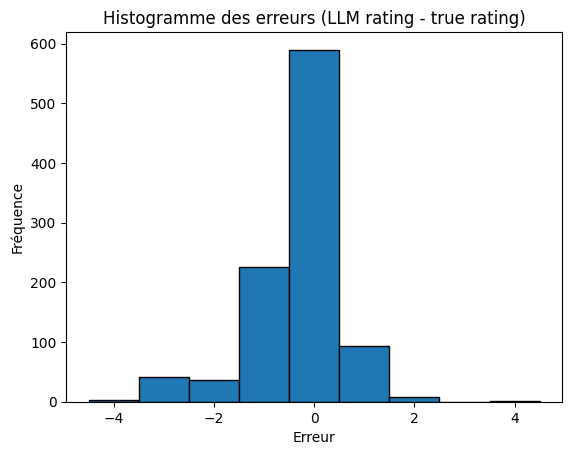

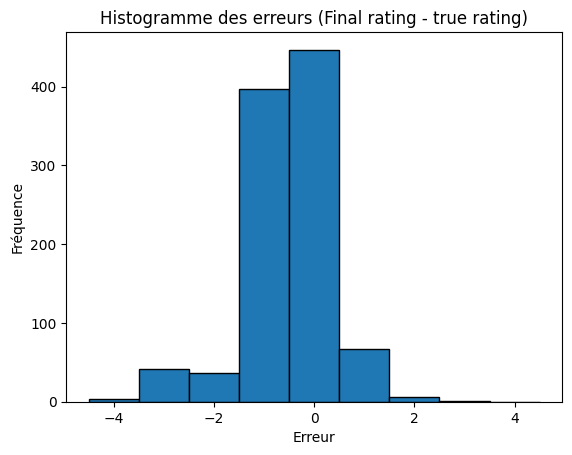

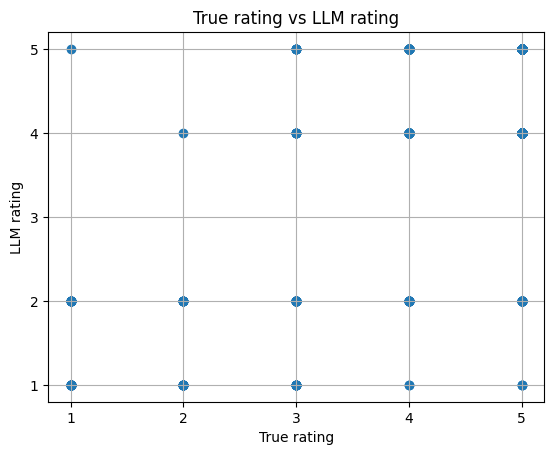

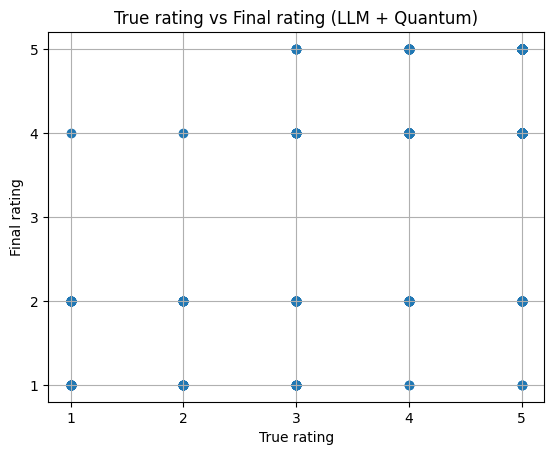

In [65]:

# Erreurs
llm_errors = llm_ratings - true_ratings
final_errors = final_ratings - true_ratings

# Histogramme des erreurs LLM
plt.figure()
plt.hist(llm_errors, bins=np.arange(-4.5, 5.5, 1), edgecolor='black')
plt.title("Histogramme des erreurs (LLM rating - true rating)")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

# Histogramme des erreurs Final
plt.figure()
plt.hist(final_errors, bins=np.arange(-4.5, 5.5, 1), edgecolor='black')
plt.title("Histogramme des erreurs (Final rating - true rating)")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

# Scatter plot : vrai vs prédiction LLM
plt.figure()
plt.scatter(true_ratings, llm_ratings)
plt.title("True rating vs LLM rating")
plt.xlabel("True rating")
plt.ylabel("LLM rating")
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.grid(True)
plt.show()

# Scatter plot : vrai vs prédiction finale
plt.figure()
plt.scatter(true_ratings, final_ratings)
plt.title("True rating vs Final rating (LLM + Quantum)")
plt.xlabel("True rating")
plt.ylabel("Final rating")
plt.xticks([1, 2, 3, 4, 5])
plt.yticks([1, 2, 3, 4, 5])
plt.grid(True)
plt.show()


## 10. Exemple détaillé d'une prédiction

In [66]:

i = random.choice(indices)
text = df.loc[i, TEXT_COL]
true_rating = int(df.loc[i, RATING_COL])

print("Review sélectionnée :\n")
print(text[:1000], "\n")

out = hybrid_predict(text)

print("Vrai rating    :", true_rating)
print("LLM rating     :", out["llm_rating"])
print("Quantum rating :", out["quantum_rating"])
print("Final rating   :", out["final_rating"])
print("\nDétails LLM :")
print(json.dumps(out["llm_raw"], indent=2))


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Review sélectionnée :

It was a little of all of her books which I have already read. 

Vrai rating    : 2
LLM rating     : 2
Quantum rating : 2
Final rating   : 2

Détails LLM :
{
  "sentiment": "neutral",
  "intensity": 0.5,
  "reasoning": "The review expresses a neutral sentiment towards the book, as the author has read it before and found it to be similar to other books by the same author. The intensity is moderate, as the author does not express extreme feelings towards the book."
}


/faststorage/project/DEIC-SDU-L2-22/env/lib64/python3.9/site-packages/pennylane/ops/op_math/controlled_ops.py:1051: UserWarning: The control_wires keyword for MultiControlledX is deprecated, and will be removed soon. Use wires = (*control_wires, target_wire) instead.
  warnings.warn(
